In [4]:
import json
import pandas as pd

data = []

with open('../../../data/raw/cafef_raw/cafef_news_2023_2026.jsonl', 'r', encoding='utf-8') as f:
    for line in f:
        data.append(json.loads(line))

df = pd.DataFrame(data)

print(df.head())
print(df.shape)

           article_id source raw_source                category  \
0  188231229103257892  cafef   category  Thị trường chứng khoán   
1  188231229094645055  cafef   category  Thị trường chứng khoán   
2  188231229082554747  cafef   category  Thị trường chứng khoán   
3  188231228162951823  cafef   category  Thị trường chứng khoán   
4  188231228183151294  cafef   category  Thị trường chứng khoán   

                                               title  \
0  Thủy điện Hủa Na (HNA) ước lãi 217 tỷ đồng, lê...   
1  Hành trình 16 năm và những dấu ấn tiên phong c...   
2  UBCKNN xử phạt Công ty Đại Nam của ông Dũng "L...   
3  Từng gây chấn động với giá gần 1 triệu đồng/cp...   
4  Góc nhìn CTCK: Rung lắc có thể sớm xuất hiện k...   

                                             summary  \
0  Ngày 12/01/2024, hơn 235 triệu cổ phiếu HNA sẽ...   
1  Hành trình 16 năm từng bước chinh phục khách h...   
2  Công ty cổ phần Đại Nam bị phạt vì có hành vi ...   
3  5 tháng kể từ thời điểm đỉnh cao 

In [6]:
df.head(5)

,article_id,source,raw_source,category,title,summary,content,url,published_at,published_date,usable_from_date,author,tags,image_url,content_length,crawled_at,crawl_error
0,188231229103257892,cafef,category,Thị trường chứng khoán,"Thủy điện Hủa Na (HNA) ước lãi 217 tỷ đồng, lê...","Ngày 12/01/2024, hơn 235 triệu cổ phiếu HNA sẽ...","HNA:\nNgày 28/12/2023, Công ty Cổ phần Chứng k...",https://cafef.vn/thuy-dien-hua-na-hna-uoc-lai-...,2023-12-29T10:27+07:00,2023-12-29,2023-12-29,Bảo Anh,thủy điện|hủa na|HoSE,https://cafefcdn.com/thumb_w/1200/203337114487...,1927,2026-06-09T23:55:45+07:00,
1,188231229094645055,cafef,category,Thị trường chứng khoán,Hành trình 16 năm và những dấu ấn tiên phong c...,Hành trình 16 năm từng bước chinh phục khách h...,DSE:\nChứng khoán DNSE tiền thân là CTCP Chứng...,https://cafef.vn/hanh-trinh-16-nam-va-nhung-da...,2023-12-29T10:00+07:00,2023-12-29,2023-12-29,Ánh Dương,DNSE|đơn giản hóa đầu tư,https://cafefcdn.com/thumb_w/1200/203337114487...,930,2026-06-09T23:55:45+07:00,
2,188231229082554747,cafef,category,Thị trường chứng khoán,"UBCKNN xử phạt Công ty Đại Nam của ông Dũng ""L...",Công ty cổ phần Đại Nam bị phạt vì có hành vi ...,"Ngày 27/12, Ủy ban Chứng khoán Nhà nước (UBCKN...",https://cafef.vn/ubcknn-xu-phat-cong-ty-dai-na...,2023-12-29T08:27+07:00,2023-12-29,2023-12-29,Mai Chi,công ty cổ phần|Ủy ban Chứng khoán Nhà nước,https://cafefcdn.com/thumb_w/1200/203337114487...,1168,2026-06-09T23:55:45+07:00,
3,188231228162951823,cafef,category,Thị trường chứng khoán,Từng gây chấn động với giá gần 1 triệu đồng/cp...,5 tháng kể từ thời điểm đỉnh cao cho tới khi b...,XDC:\nNhà đầu tư trên thị trường chứng khoán đ...,https://cafef.vn/tung-gay-chan-dong-voi-gia-ga...,2023-12-29T00:06+07:00,2023-12-29,2023-12-29,Phương Linh,chứng khoán|cổ phiếu|XDC,https://cafefcdn.com/thumb_w/1200/203337114487...,3349,2026-06-09T23:55:45+07:00,
4,188231228183151294,cafef,category,Thị trường chứng khoán,Góc nhìn CTCK: Rung lắc có thể sớm xuất hiện k...,"Nhận định về thị trường phiên tới, các CTCK đa...",VN-Index trải qua một nhịp bứt phá với đà...,https://cafef.vn/goc-nhin-ctck-rung-lac-co-the...,2023-12-28T18:33+07:00,2023-12-28,2023-12-29,Năm Dòng Kẻ,nhà đầu tư|cổ phiếu vốn hóa lớn,https://cafefcdn.com/thumb_w/1200/203337114487...,3441,2026-06-09T23:55:45+07:00,


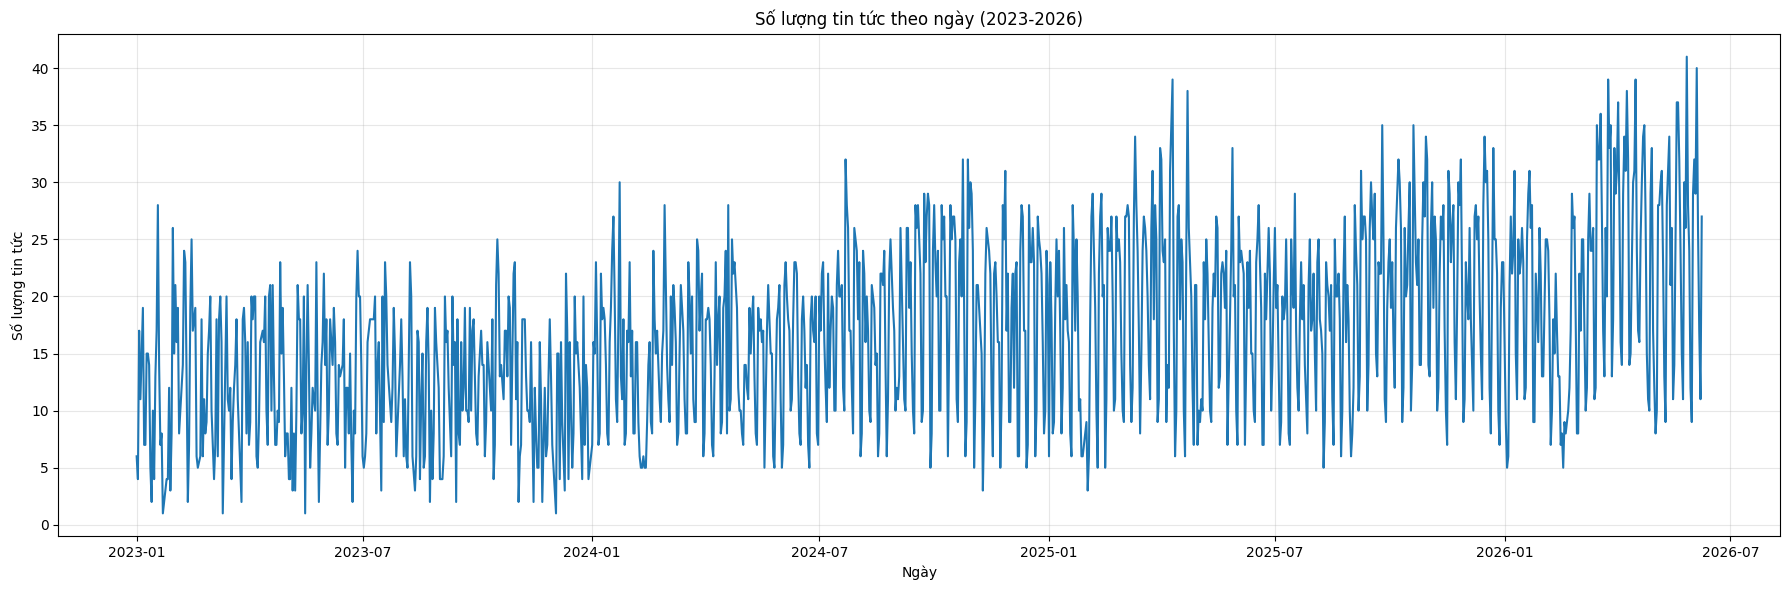

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
# Chuyển sang datetime
df["publish_date"] = pd.to_datetime(df["published_date"], errors="coerce")

# Loại bỏ các dòng lỗi ngày tháng
df = df.dropna(subset=["publish_date"])

# Lấy phần ngày (bỏ giờ phút giây)
df["date"] = df["publish_date"].dt.date

# Đếm số bài báo mỗi ngày
daily_counts = (
    df.groupby("date")
      .size()
      .reset_index(name="news_count")
      .sort_values("date")
)

# Vẽ biểu đồ
plt.figure(figsize=(18, 6))
plt.plot(daily_counts["date"], daily_counts["news_count"])
plt.title("Số lượng tin tức theo ngày (2023-2026)")
plt.xlabel("Ngày")
plt.ylabel("Số lượng tin tức")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [8]:
df["publish_date"] = pd.to_datetime(df["published_date"], errors="coerce")

# Chỉ lấy ngày
dates = pd.to_datetime(df["publish_date"].dt.date)

# Các ngày thực tế có trong dữ liệu
existing_dates = set(dates.unique())

# Khoảng ngày đầy đủ
full_dates = set(
    pd.date_range(
        start=min(existing_dates),
        end=max(existing_dates),
        freq="D"
    )
)

# Các ngày bị thiếu
missing_dates = sorted(full_dates - existing_dates)

print(f"Số ngày bị thiếu: {len(missing_dates)}")

for d in missing_dates:
    print(d.strftime("%Y-%m-%d"))

Số ngày bị thiếu: 38
2023-01-23
2023-01-24
2023-02-05
2023-02-06
2023-02-20
2023-03-03
2023-03-12
2023-03-13
2023-03-24
2023-03-25
2023-04-11
2023-05-23
2023-05-28
2023-06-06
2023-06-14
2023-07-08
2023-07-09
2023-07-15
2023-07-22
2023-07-23
2023-07-29
2023-07-30
2023-08-11
2023-09-02
2023-09-09
2023-10-03
2023-10-11
2023-10-21
2023-10-29
2023-11-07
2023-11-14
2023-11-23
2023-12-01
2023-12-02
2023-12-09
2023-12-23
2023-12-30
2023-12-31
